**powershell 에서 uv add langraph로 모듈 설치**

In [1]:
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

model = ChatOllama(model="gemma4:e2b", base_url="http://127.0.0.1:11434") 
model.invoke('안녕하세요!')

AIMessage(content='안녕하세요! 만나서 반갑습니다. 😊\n\n저는 사용자님을 돕기 위해 여기에 있습니다. 궁금한 점이 있거나, 도움이 필요하거나, 그냥 이야기하고 싶으실 때 언제든지 말씀해주세요!', additional_kwargs={}, response_metadata={'model': 'gemma4:e2b', 'created_at': '2026-08-21T02:24:28.4834611Z', 'done': True, 'done_reason': 'stop', 'total_duration': 6972843700, 'load_duration': 6484593800, 'prompt_eval_count': 18, 'prompt_eval_duration': 93153000, 'eval_count': 43, 'eval_duration': 391468000, 'logprobs': None, 'model_name': 'gemma4:e2b', 'model_provider': 'ollama'}, id='lc_run--01a02222-3204-7191-92c3-faf65c3af9cf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 43, 'total_tokens': 61})

In [2]:
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 클래스

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):	#①
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다.   #②
       'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.  #③
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다)
    """
    messages: Annotated[list[str], add_messages]	#②

# StateGraph 클래스를 사용하여 State 타입의 그래프를 생성합니다.
graph_builder = StateGraph(State) #④

In [3]:
def generate(state: State):	#①
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.
		
    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리. 
          형식은 {"messages": [응답 메시지]}입니다.
    """ 
    return {"messages": [model.invoke(state["messages"])]}	#②

graph_builder.add_node("generate", generate)	#③

In [4]:
graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", END)    

graph = graph_builder.compile()

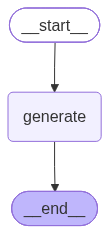

In [5]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception: 
    pass

In [9]:
response = graph.invoke({"messages": ["안녕하세요! 저는 정성락입니다"]})

print(type(response))
response

<class 'dict'>


{'messages': [HumanMessage(content='안녕하세요! 저는 정성락입니다', additional_kwargs={}, response_metadata={}, id='f16b1877-384b-4058-8e41-69d861abe81a'),
  AIMessage(content='안녕하세요, 정성락님! 만나서 반갑습니다. 😊\n\n저는 사용자님을 돕기 위해 준비되어 있습니다. 궁금한 점이 있으시거나 도움이 필요하시면 언제든지 말씀해주세요!', additional_kwargs={}, response_metadata={'model': 'gemma4:e2b', 'created_at': '2026-08-21T02:40:49.8836156Z', 'done': True, 'done_reason': 'stop', 'total_duration': 61208129500, 'load_duration': 60695496000, 'prompt_eval_count': 23, 'prompt_eval_duration': 116412000, 'eval_count': 41, 'eval_duration': 392205000, 'logprobs': None, 'model_name': 'gemma4:e2b', 'model_provider': 'ollama'}, id='lc_run--01a02230-57c1-7b42-9512-aa814cce4aa9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 23, 'output_tokens': 41, 'total_tokens': 64})]}

In [10]:
response["messages"].append("제 이름을 아시나요?")
graph.invoke(response)

{'messages': [HumanMessage(content='안녕하세요! 저는 정성락입니다', additional_kwargs={}, response_metadata={}, id='f16b1877-384b-4058-8e41-69d861abe81a'),
  AIMessage(content='안녕하세요, 정성락님! 만나서 반갑습니다. 😊\n\n저는 사용자님을 돕기 위해 준비되어 있습니다. 궁금한 점이 있으시거나 도움이 필요하시면 언제든지 말씀해주세요!', additional_kwargs={}, response_metadata={'model': 'gemma4:e2b', 'created_at': '2026-08-21T02:40:49.8836156Z', 'done': True, 'done_reason': 'stop', 'total_duration': 61208129500, 'load_duration': 60695496000, 'prompt_eval_count': 23, 'prompt_eval_duration': 116412000, 'eval_count': 41, 'eval_duration': 392205000, 'logprobs': None, 'model_name': 'gemma4:e2b', 'model_provider': 'ollama'}, id='lc_run--01a02230-57c1-7b42-9512-aa814cce4aa9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 23, 'output_tokens': 41, 'total_tokens': 64}),
  HumanMessage(content='제 이름을 아시나요?', additional_kwargs={}, response_metadata={}, id='78f9f839-53f8-4380-8023-bd3f19b7aec6'),
  AIMessage(content='네, 알고 있습니다. 방금 말씀해주신 성함은 **정성락** 님입니다

In [8]:
inputs = {"messages": [("human", "한국과 일본의 관계에 대해 자세히 알려줘")]}
for chunk, _ in graph.stream(inputs, stream_mode="messages"):
    print(chunk.content, end="")

한국과 일본의 관계는 역사적 경험, 지리적 근접성, 그리고 현재의 복잡한 지정학적 상황이 얽혀 있어 매우 다층적이고 복잡합니다. 양국은 과거의 갈등을 극복하고 현재는 경제적, 문화적으로 깊은 상호 의존 관계를 형성하고 있지만, 여전히 해결되지 않은 역사적 문제와 안보적 이슈가 존재합니다.

다음은 한국과 일본 관계를 주요 측면별로 자세히 설명한 내용입니다.

---

## 1. 역사적 배경 (Historical Context)

한국과 일본의 관계는 일제강점기라는 강제 점령의 역사에서 시작되었습니다.

### 1) 일제강점기 (1910~1945)
*   **식민 지배:** 일본 제국주의는 약 35년간 한국을 식민 지배했으며, 이 과정에서 한국 민족에게 깊은 고통과 피해를 안겨주었습니다.
*   **갈등의 씨앗:** 식민 지배 과정에서 발생한 수많은 강제 동원, 징용, 그리고 일본 제국주의의 침략 행위는 현재까지 양국 관계에 있어 민감한 역사적 쟁점으로 남아 있습니다.

### 2) 전후 관계와 화해 노력 (Post-War Relations)
*   **전후 질서:** 제2차 세계대전 이후, 연합국(미국, 소련 등)의 영향 아래에서 한국과 일본은 점진적으로 관계를 재정립하기 시작했습니다.
*   **화해와 협력:** 전쟁의 피해를 극복하고 평화적인 공존을 모색하기 위해 양국은 경제적 협력과 외교적 관계를 강화해왔습니다.

## 2. 현재의 관계: 상호 의존성과 협력 (Interdependence and Cooperation)

현재 양국 관계의 가장 두드러진 특징은 **경제적 상호 의존성**과 **외교적 협력**입니다.

### 1) 경제적 관계 (Economic Ties)
*   **주요 무역 파트너:** 일본은 한국의 가장 중요한 교역 상대국 중 하나입니다. 한국의 주요 수출 품목과 일본의 첨단 기술 및 소비재 시장은 상호 발전의 기반이 되고 있습니다.
*   **투자 및 기술 교류:** 양국 간의 대규모 투자와 기술 협력은 첨단 산업(반도체, 자동차, IT